### Imports

In [25]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pyopencl as cl

### 8a RGB-Bild einlesen und in ein Graustufenbild umwandeln

In [26]:
image_path = Path("images_input/1.nature_small.jpeg")

image = Image.open(image_path)
rgb_matrix = np.array(image, dtype=np.uint8)

height, width, channels = rgb_matrix.shape
pixel_count = height * width

rgb_flat = rgb_matrix.flatten()
gray_flat = np.empty(pixel_count, dtype=np.uint8)

context = cl.create_some_context()
queue = cl.CommandQueue(context)

mf = cl.mem_flags
rgb_input_buffer  = cl.Buffer(context,  mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=rgb_flat)
gray_output_buffer = cl.Buffer(context, mf.WRITE_ONLY, gray_flat.nbytes)

program = cl.Program(context, """
__kernel void rgb_to_grayscale(
    __global const uchar *rgb,
    __global uchar *gray
)
{
    int pixel_id = get_global_id(0);
    int rgb_id = pixel_id * 3;

    uchar red = rgb[rgb_id];
    uchar green = rgb[rgb_id + 1];
    uchar blue = rgb[rgb_id + 2];

    gray[pixel_id] = (uchar)(0.21f * red + 0.72f * green + 0.07f * blue);
}
""").build()

program.rgb_to_grayscale(
    queue,
    (pixel_count,),
    None,
    rgb_input_buffer ,
    gray_output_buffer
)

cl.enqueue_copy(queue, gray_flat, gray_output_buffer)

gray_matrix = gray_flat.reshape((height, width))

# plt.imshow(gray_matrix, cmap="gray", vmin=0, vmax=255)
# plt.axis("off")
# plt.show()

### 8b Helligkeit und Kontrast vom Graustufenbild anpassen

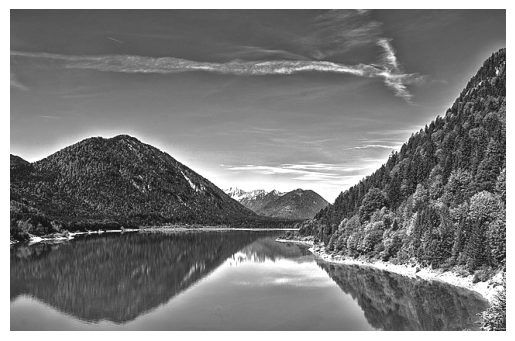

In [27]:
alpha = np.float32(1.3)
beta = np.float32(20)

gray_matrix_2_flat = np.empty(pixel_count, dtype=np.uint8)

gray_input_buffer = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=gray_flat)
gray_output_buffer_2 = cl.Buffer(context, mf.WRITE_ONLY, gray_matrix_2_flat.nbytes)

program = cl.Program(context, """
__kernel void adjust_brightness_contrast(
    __global const uchar *gray,
    __global uchar *gray_out,
    const float alpha,
    const float beta
)
{
    int pixel_id = get_global_id(0);

    float value = alpha * gray[pixel_id] + beta;

    if (value < 0.0f) {
        value = 0.0f;
    }

    if (value > 255.0f) {
        value = 255.0f;
    }

    gray_out[pixel_id] = (uchar)(value);
}
""").build()

program.adjust_brightness_contrast(
    queue,
    (pixel_count,),
    None,
    gray_input_buffer,
    gray_output_buffer_2,
    alpha,
    beta
)

cl.enqueue_copy(queue, gray_matrix_2_flat, gray_output_buffer_2)

gray_matrix_2 = gray_matrix_2_flat.reshape((height, width))

plt.imshow(gray_matrix_2, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()